# 🏢 Visualizaciones Finales — TFM Tasador Inmobiliario Multimodal

**Dataset:** 5.031 propiedades reales del mercado inmobiliario de Madrid  
**Etiquetadas visualmente por IA (VLM):** 781 propiedades  
**Distribución:** Lujo (177) | Buen estado (530) | A reformar (74)

---

Este notebook está organizado en **dos secciones**:

| Sección | Propósito | Librería |
|---------|-----------|----------|
| **A — Memoria TFM** | Gráficos estáticos, alta resolución (300 DPI), listos para incluir en Word/PDF | Matplotlib + Seaborn |
| **B — App Streamlit** | Código modular interactivo listo para copiar en `app.py` | Plotly |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# ── Alta resolución para la Memoria del TFM ──
plt.rcParams.update({
    'figure.dpi': 150,          # 300 DPI al guardar con savefig
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})
sns.set_theme(style="whitegrid", palette="muted")

# Carpeta de exportación
os.makedirs('graficas_exportadas', exist_ok=True)
print("✅ Configuración cargada.")


✅ Configuración cargada.


In [2]:
# ── Carga de datos ──
df_limpias   = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')
df_etiq      = pd.read_csv('../data_pipeline/data/processed/propiedades_etiquetadas.csv')

# Columnas de interés de etiquetadas
df_etiq_cols = df_etiq[['id_inmueble', 'estado_conservacion', 'calidad_materiales']]

# Merge: conservamos las 5.031 propiedades, rellenando NaN con 'No etiquetado'
df = pd.merge(df_limpias, df_etiq_cols, on='id_inmueble', how='left')
df['estado_conservacion'] = df['estado_conservacion'].fillna('No etiquetado')
df['calidad_materiales']  = df['calidad_materiales'].fillna('No etiquetado')

# Transformación log (para gráfica A.1)
df['precio_log'] = np.log1p(df['precio_limpio'])

print(f"✅ Dataset cargado: {len(df):,} propiedades")
print(f"   → Etiquetadas por IA: {(df['estado_conservacion'] != 'No etiquetado').sum():,}")
print(f"   → Precio mediano: {df['precio_limpio'].median():,.0f} €")
print(f"   → Precio/m² mediano: {df['precio_m2'].median():,.0f} €/m²")
print()
print("Distribución de estado_conservacion:")
print(df['estado_conservacion'].value_counts())


✅ Dataset cargado: 5,031 propiedades
   → Etiquetadas por IA: 781
   → Precio mediano: 620,000 €
   → Precio/m² mediano: 6,195 €/m²

Distribución de estado_conservacion:
estado_conservacion
No etiquetado    4250
Buen estado       530
Lujo              177
A reformar         74
Name: count, dtype: int64


---
## 📄 Sección A — Gráficas para la Memoria del TFM

> Todas las figuras se guardan automáticamente en `graficas_exportadas/` con 300 DPI.


### A.1 — Transformación de la Variable Target (Precio)

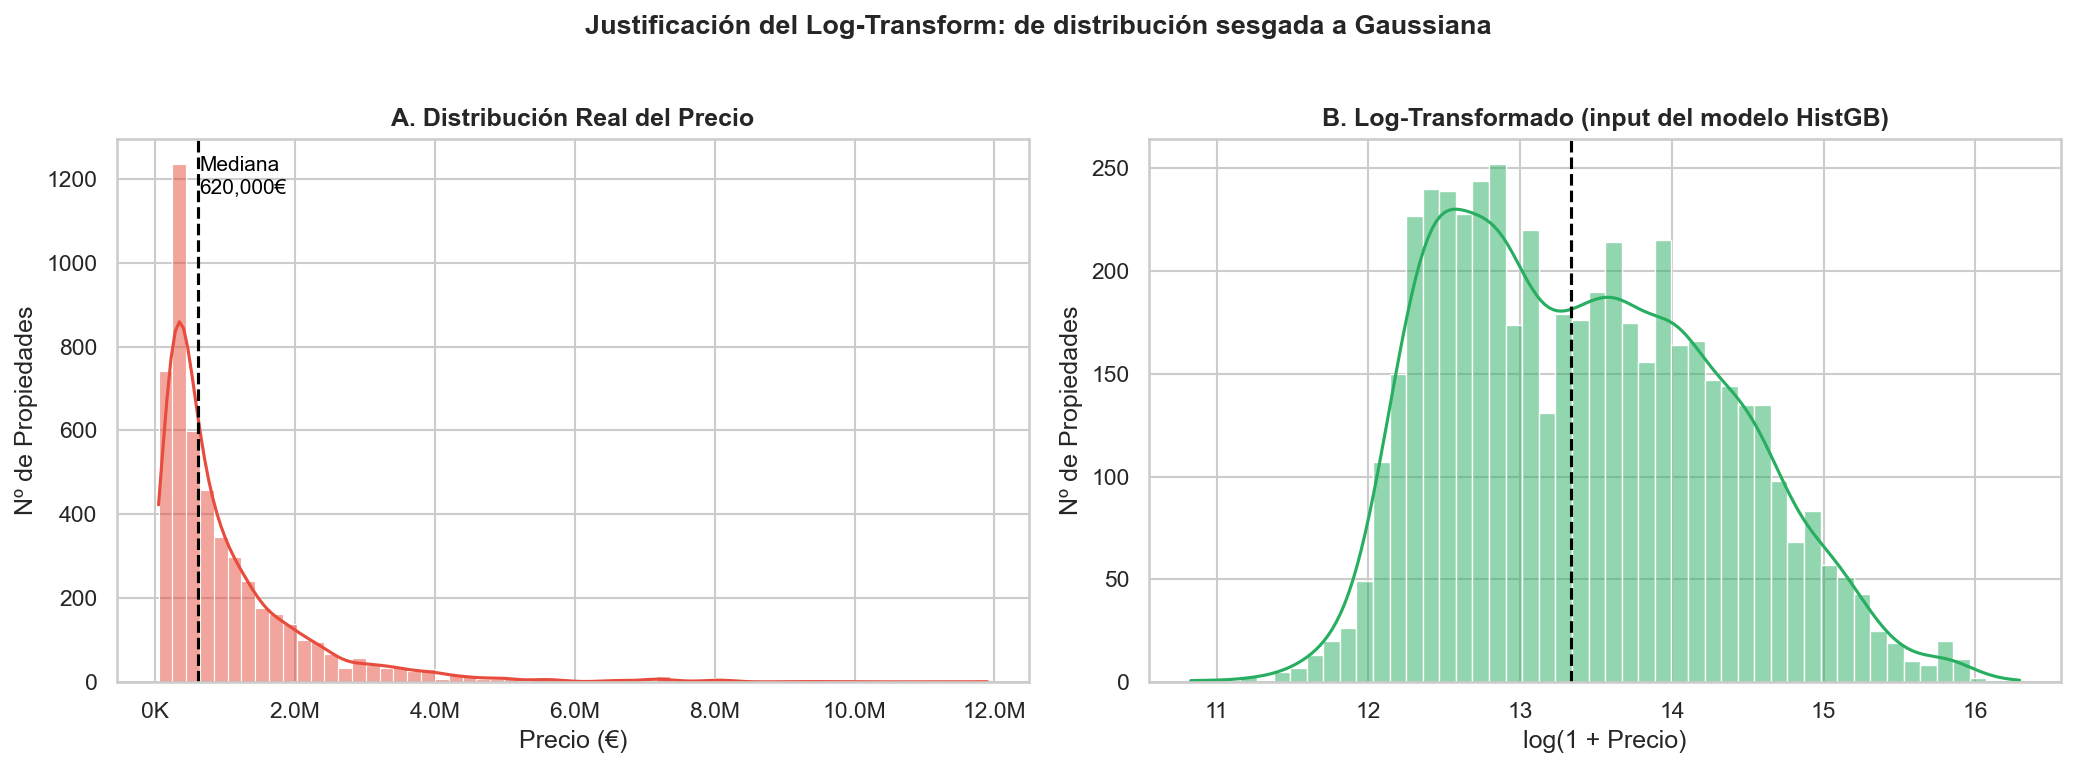

✅ Guardado: A1_Transformacion_Precio.png


In [3]:
# A.1. Por qué usamos Log(Precio) como target en el modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: distribución real con asimetría ──
sns.histplot(df['precio_limpio'], bins=60, kde=True, color='#e74c3c', ax=axes[0])
axes[0].set_title('A. Distribución Real del Precio', weight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Nº de Propiedades')
# Formato de eje sin notación científica
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'))

# Anotación
axes[0].axvline(df['precio_limpio'].median(), color='black', linestyle='--', linewidth=1.5)
axes[0].text(df['precio_limpio'].median() * 1.02,
             axes[0].get_ylim()[1] * 0.9,
             f"Mediana\n{df['precio_limpio'].median():,.0f}€",
             fontsize=10, color='black')

# ── Derecha: log-transformado ──
sns.histplot(df['precio_log'], bins=50, kde=True, color='#27ae60', ax=axes[1])
axes[1].set_title('B. Log-Transformado (input del modelo HistGB)', weight='bold')
axes[1].set_xlabel('log(1 + Precio)')
axes[1].set_ylabel('Nº de Propiedades')
axes[1].axvline(df['precio_log'].median(), color='black', linestyle='--', linewidth=1.5)

plt.suptitle('Justificación del Log-Transform: de distribución sesgada a Gaussiana',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficas_exportadas/A1_Transformacion_Precio.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: A1_Transformacion_Precio.png")


### A.2 — Matriz de Correlación de Features

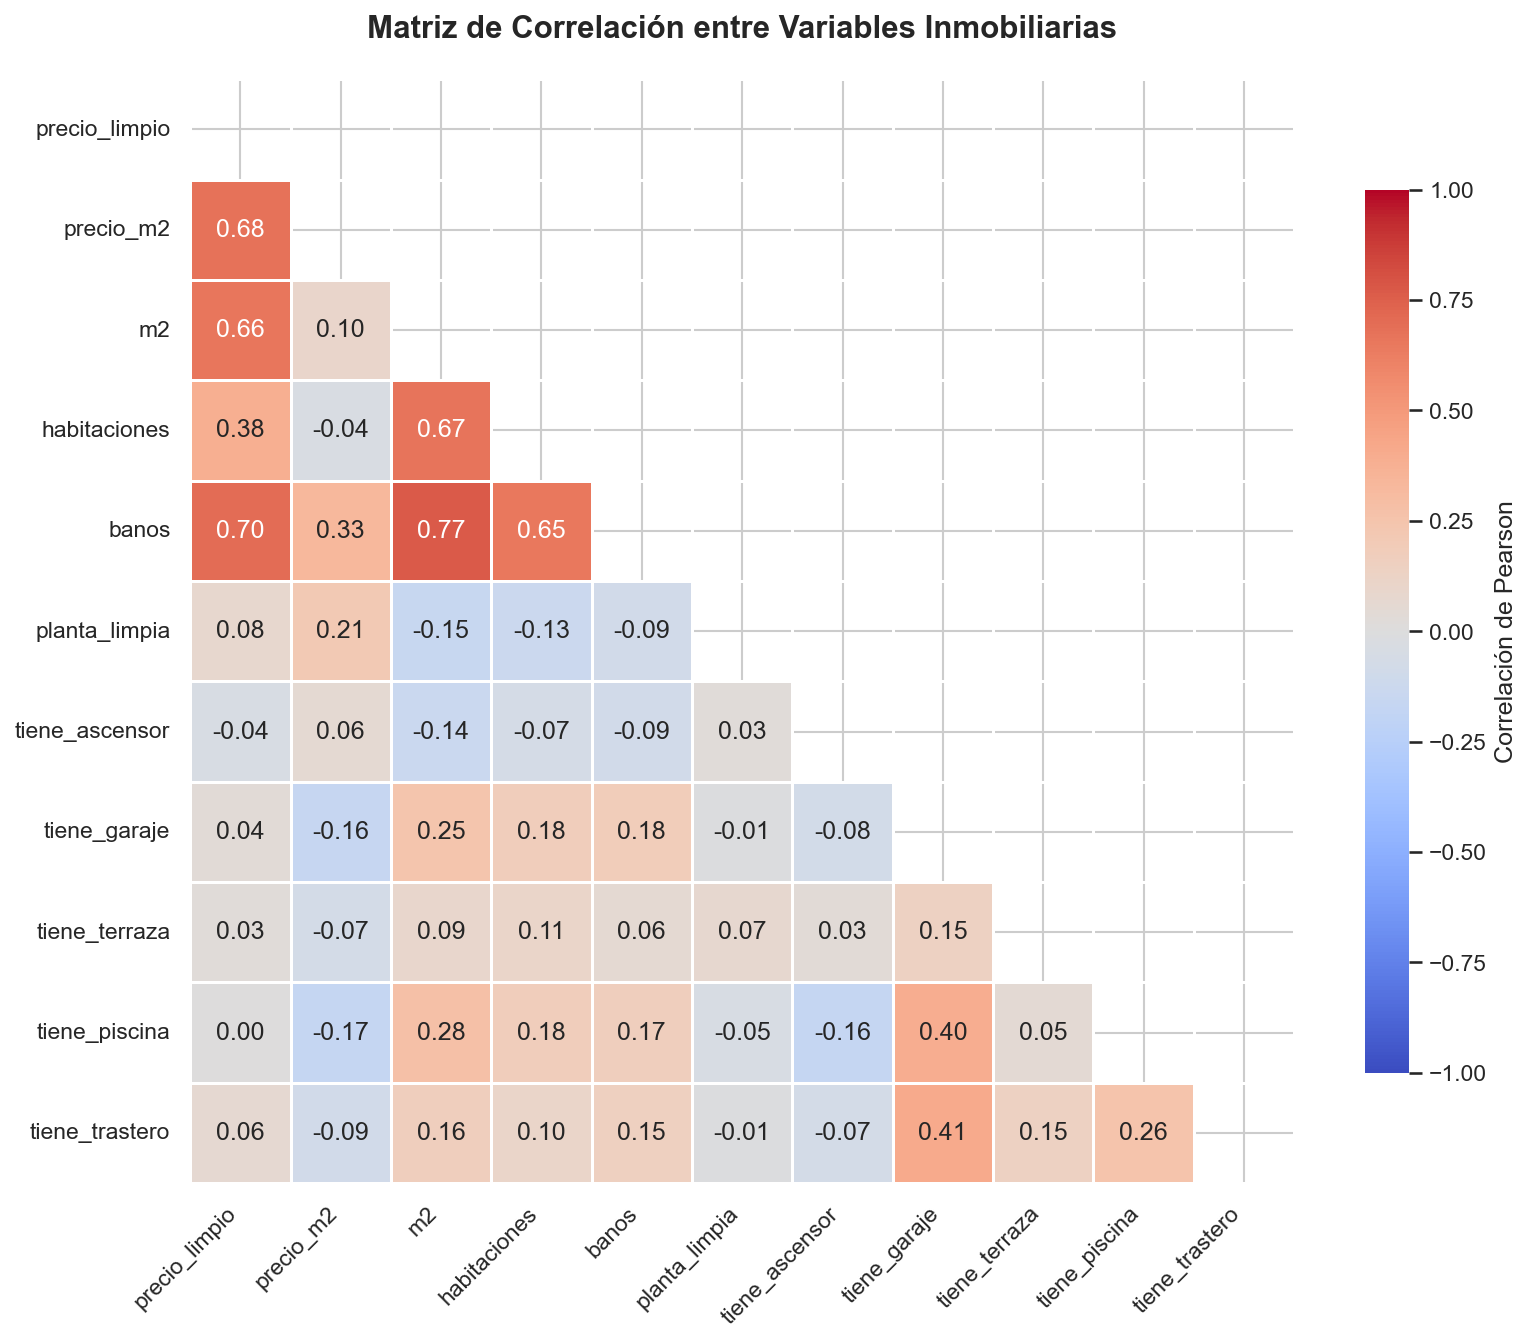

✅ Guardado: A2_Correlacion.png


In [4]:
# A.2. Mapa de calor de correlaciones (triángulo inferior)
cols_corr = ['precio_limpio', 'precio_m2', 'm2', 'habitaciones', 'banos',
             'planta_limpia', 'tiene_ascensor', 'tiene_garaje',
             'tiene_terraza', 'tiene_piscina', 'tiene_trastero']

cols_exist = [c for c in cols_corr if c in df.columns]
corr = df[cols_exist].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # ocultar triángulo superior

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"})
plt.title("Matriz de Correlación entre Variables Inmobiliarias", fontsize=15, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graficas_exportadas/A2_Correlacion.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: A2_Correlacion.png")


### A.3 — Impacto Real de las Amenidades (Mediana, robusto ante outliers)

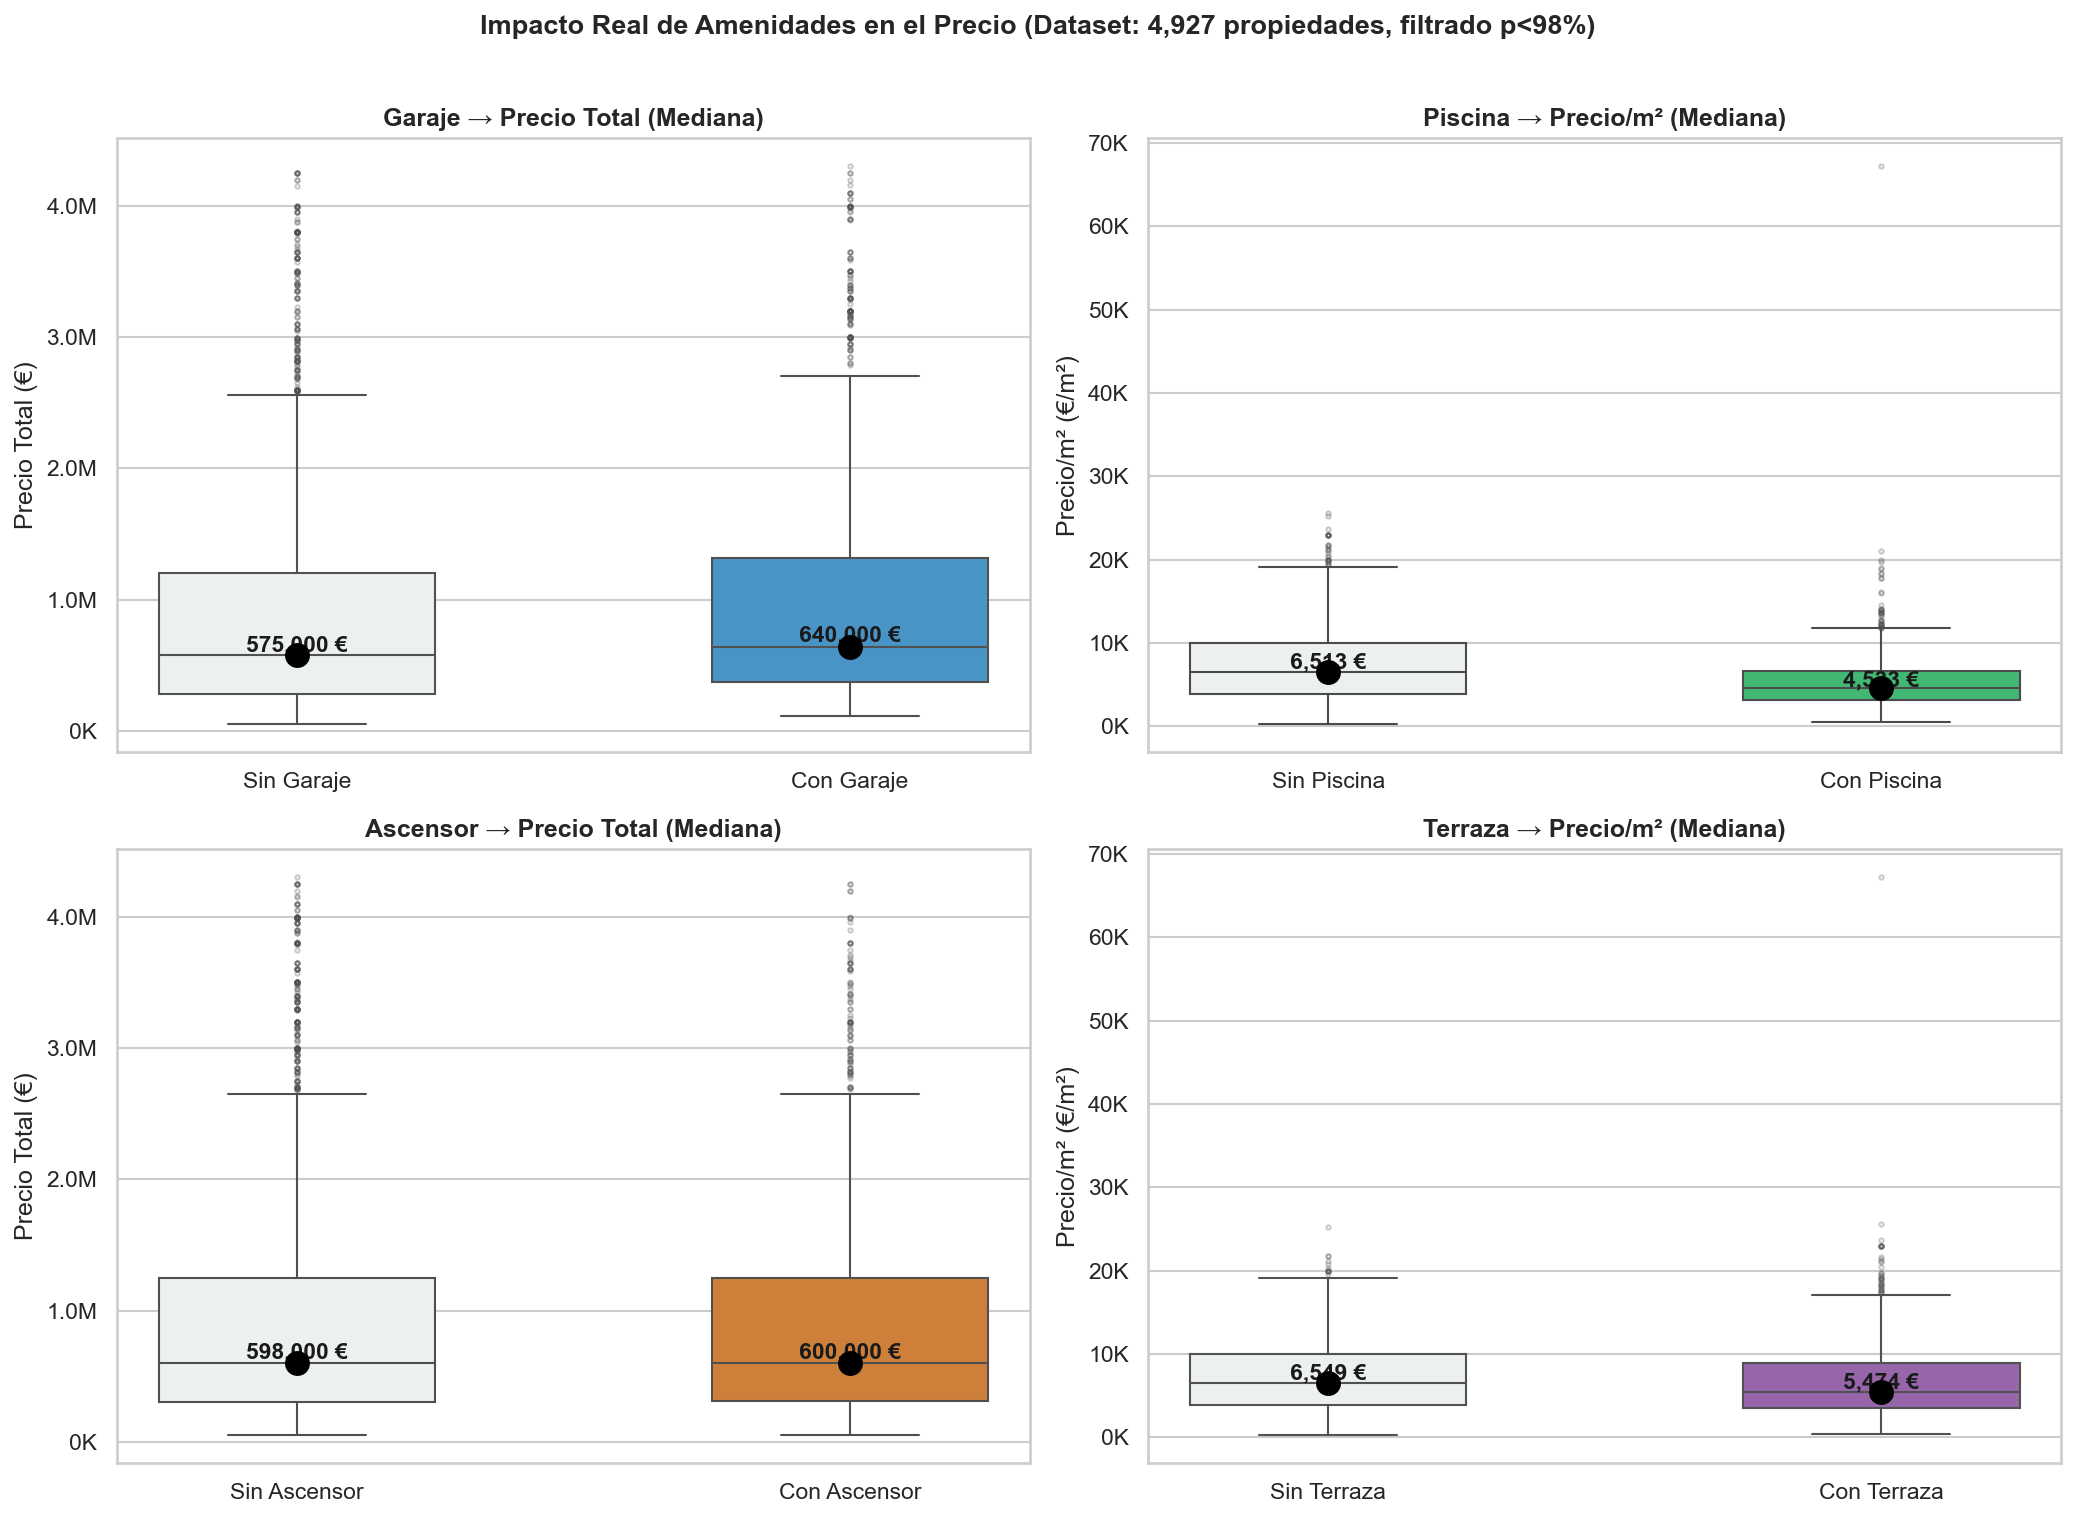


📊 TABLA RESUMEN — Diferencia de Mediana por Amenidad:
Amenidad             Sin (Mediana)        Con (Mediana)        Diferencia (€)  % Incremento
-------------------------------------------------------------------------------------
Garaje → Precio Tota            575,000 €            640,000 €       65,000 €  +11.3%
Piscina → Precio/m²               6,513 €              4,533 €       -1,980 €  +-30.4%
Ascensor → Precio To            598,000 €            600,000 €        2,000 €  +0.3%
Terraza → Precio/m²               6,549 €              5,474 €       -1,075 €  +-16.4%
✅ Guardado: A3_Impacto_Amenidades.png


In [5]:
# A.3. Impacto de Amenidades usando MEDIANA (no media, que se ve distorsionada por propiedades de >5M€)
# Filtramos outliers solo para la visualización (percentil 98)
P98 = df['precio_limpio'].quantile(0.98)
df_viz = df[df['precio_limpio'] < P98].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

amenidades_config = [
    ('tiene_garaje',   'precio_limpio', 'Sin Garaje', 'Con Garaje',   'Garaje → Precio Total (Mediana)',   '#3498db'),
    ('tiene_piscina',  'precio_m2',     'Sin Piscina','Con Piscina',  'Piscina → Precio/m² (Mediana)',     '#2ecc71'),
    ('tiene_ascensor', 'precio_limpio', 'Sin Ascensor','Con Ascensor','Ascensor → Precio Total (Mediana)', '#e67e22'),
    ('tiene_terraza',  'precio_m2',     'Sin Terraza', 'Con Terraza', 'Terraza → Precio/m² (Mediana)',     '#9b59b6'),
]

for ax, (col_x, col_y, label0, label1, titulo, color) in zip(axes, amenidades_config):
    # Boxplot de fondo
    sns.boxplot(x=col_x, y=col_y, data=df_viz, ax=ax, palette=['#ecf0f1', color], width=0.5,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    # Overlay: mediana como punto
    medians = df_viz.groupby(col_x)[col_y].median()
    ax.scatter([0, 1], medians.values, s=120, color='black', zorder=5, label='Mediana')
    for i, (xp, med) in enumerate(zip([0, 1], medians.values)):
        ax.text(xp, med * 1.06, f'{med:,.0f} €', ha='center', fontsize=11,
                fontweight='bold', color='#1a1a1a')
    ax.set_title(titulo, weight='bold')
    ax.set_xticklabels([label0, label1])
    ax.set_xlabel('')
    col_y_label = 'Precio Total (€)' if col_y == 'precio_limpio' else 'Precio/m² (€/m²)'
    ax.set_ylabel(col_y_label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'))

plt.suptitle(f'Impacto Real de Amenidades en el Precio (Dataset: {len(df_viz):,} propiedades, filtrado p<98%)',
             fontsize=13, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficas_exportadas/A3_Impacto_Amenidades.png', bbox_inches='tight')
plt.show()

# ── Tabla resumen ──
print("\n📊 TABLA RESUMEN — Diferencia de Mediana por Amenidad:")
print(f"{'Amenidad':<20} {'Sin (Mediana)':<20} {'Con (Mediana)':<20} {'Diferencia (€)':<15} {'% Incremento'}")
print("-" * 85)
for col_x, col_y, label0, label1, titulo, _ in amenidades_config:
    m0 = df_viz.groupby(col_x)[col_y].median()[0]
    m1 = df_viz.groupby(col_x)[col_y].median()[1]
    diff = m1 - m0
    pct  = (diff / m0) * 100
    print(f"{titulo[:20]:<20} {m0:>18,.0f} € {m1:>18,.0f} € {diff:>12,.0f} €  +{pct:.1f}%")
print("✅ Guardado: A3_Impacto_Amenidades.png")


### A.4 — Validación del Etiquetado Visual por IA (VLM)

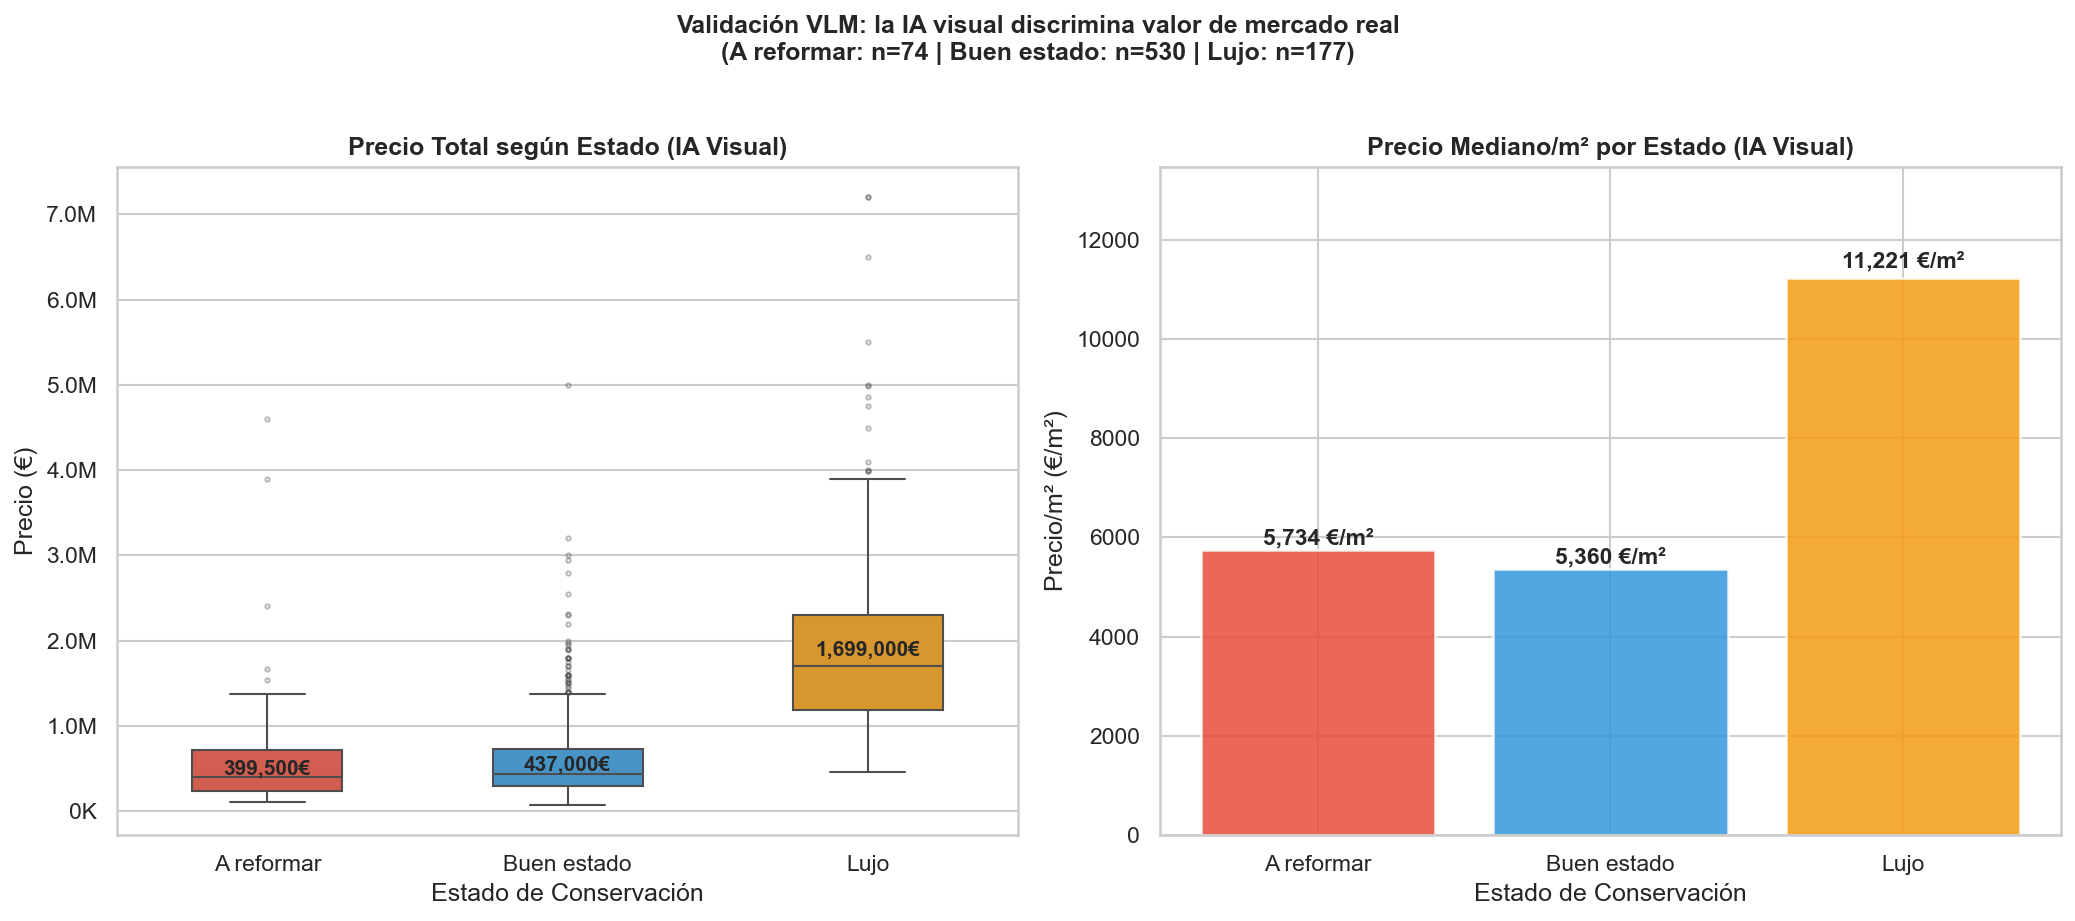

✅ Guardado: A4_Validacion_IA.png


In [6]:
# A.4. El etiquetado visual del VLM captura valor real?
df_ia = df[df['estado_conservacion'] != 'No etiquetado'].copy()
orden = ['A reformar', 'Buen estado', 'Lujo']
palette = {'A reformar': '#e74c3c', 'Buen estado': '#3498db', 'Lujo': '#f39c12'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot precio total
sns.boxplot(x='estado_conservacion', y='precio_limpio', data=df_ia, order=orden,
            palette=palette, ax=axes[0], width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
axes[0].set_title('Precio Total según Estado (IA Visual)', weight='bold')
axes[0].set_xlabel('Estado de Conservación')
axes[0].set_ylabel('Precio (€)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'))

# Anotar medianas
for i, est in enumerate(orden):
    med = df_ia[df_ia['estado_conservacion'] == est]['precio_limpio'].median()
    axes[0].text(i, med * 1.07, f'{med:,.0f}€', ha='center', fontsize=10, fontweight='bold')

# Barras con precio mediano por m²
medians_m2 = df_ia.groupby('estado_conservacion')['precio_m2'].median()[orden].reset_index()
bars = axes[1].bar(medians_m2['estado_conservacion'], medians_m2['precio_m2'],
                   color=[palette[e] for e in orden], alpha=0.85, edgecolor='white', linewidth=1.2)
axes[1].set_title('Precio Mediano/m² por Estado (IA Visual)', weight='bold')
axes[1].set_xlabel('Estado de Conservación')
axes[1].set_ylabel('Precio/m² (€/m²)')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.02,
                 f'{int(bar.get_height()):,} €/m²',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, medians_m2['precio_m2'].max() * 1.2)

# Nota de muestra
n_str = ' | '.join([f"{e}: n={len(df_ia[df_ia['estado_conservacion']==e])}" for e in orden])
plt.suptitle(f'Validación VLM: la IA visual discrimina valor de mercado real\n({n_str})',
             fontsize=12, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficas_exportadas/A4_Validacion_IA.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: A4_Validacion_IA.png")


### A.5 — Ranking de Barrios por Precio/m²

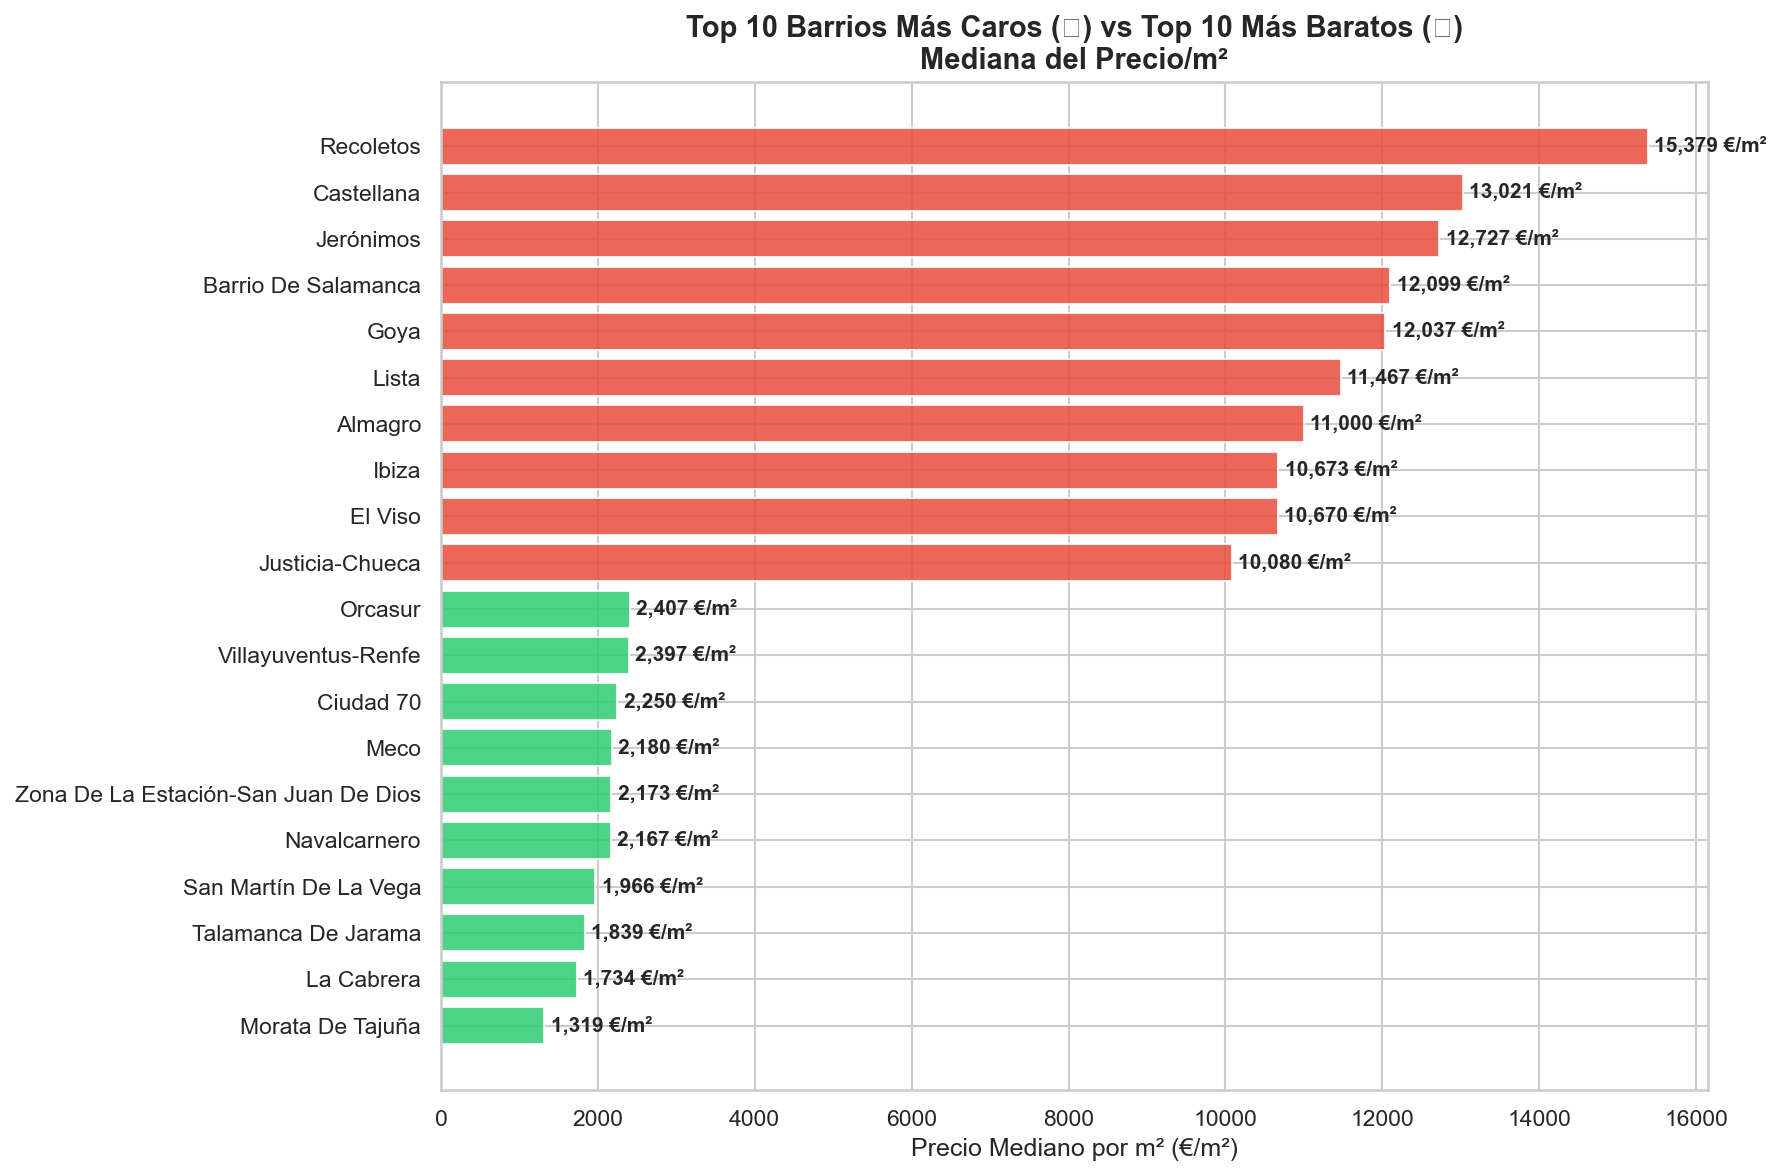

✅ Guardado: A5_Ranking_Barrios.png


In [7]:
# A.5. Top barrios más caros y más baratos
precio_barrio = df.groupby('barrio_limpio')['precio_m2'].agg(['median', 'count'])
precio_barrio = precio_barrio[precio_barrio['count'] >= 5]  # Solo barrios con ≥5 propiedades
precio_barrio = precio_barrio['median'].sort_values(ascending=False)

top_caros  = precio_barrio.head(10)
top_barats = precio_barrio.tail(10)
combined   = pd.concat([top_barats, top_caros]).sort_values()

colors = ['#e74c3c' if v > precio_barrio.median() else '#2ecc71' for v in combined.values]

plt.figure(figsize=(12, 8))
bars = plt.barh(combined.index, combined.values, color=colors, alpha=0.85, edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,} €/m²', va='center', fontsize=10, fontweight='bold')
plt.title('Top 10 Barrios Más Caros (🔴) vs Top 10 Más Baratos (🟢)\nMediana del Precio/m²',
          fontsize=14, weight='bold')
plt.xlabel('Precio Mediano por m² (€/m²)', fontsize=12)
plt.tight_layout()
plt.savefig('graficas_exportadas/A5_Ranking_Barrios.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: A5_Ranking_Barrios.png")


### A.6 — El Efecto Simpson: Por Qué la Piscina y el Estado "Parecen" Bajar el Precio/m²

> **Paradoja de Simpson:** Una tendencia aparente en datos agregados se invierte al desagregar por subgrupos, 
> revelando una **variable de confusión oculta**.
>
> En nuestro dataset ocurre en dos casos:
> - **Piscina:** Las casas CON piscina son chalets grandes en las afueras (precio/m² bajo por tipología).  
>   Las SIN piscina son pisos pequeños en el centro (precio/m² alto por ubicación prime).
> - **Estado de conservación:** El VLM etiquetó propiedades en barrios premium, por lo que "A reformar"  
>   puede aparecer caro por **ubicación geográfica**, no por su estado de conservación.
>
> **Conclusión:** El barrio/tipo de inmueble es la variable dominante. El modelo la captura correctamente  
> mediante `target_encoding_m2` y los `ratios zona`. El estado físico ajusta ese valor base.


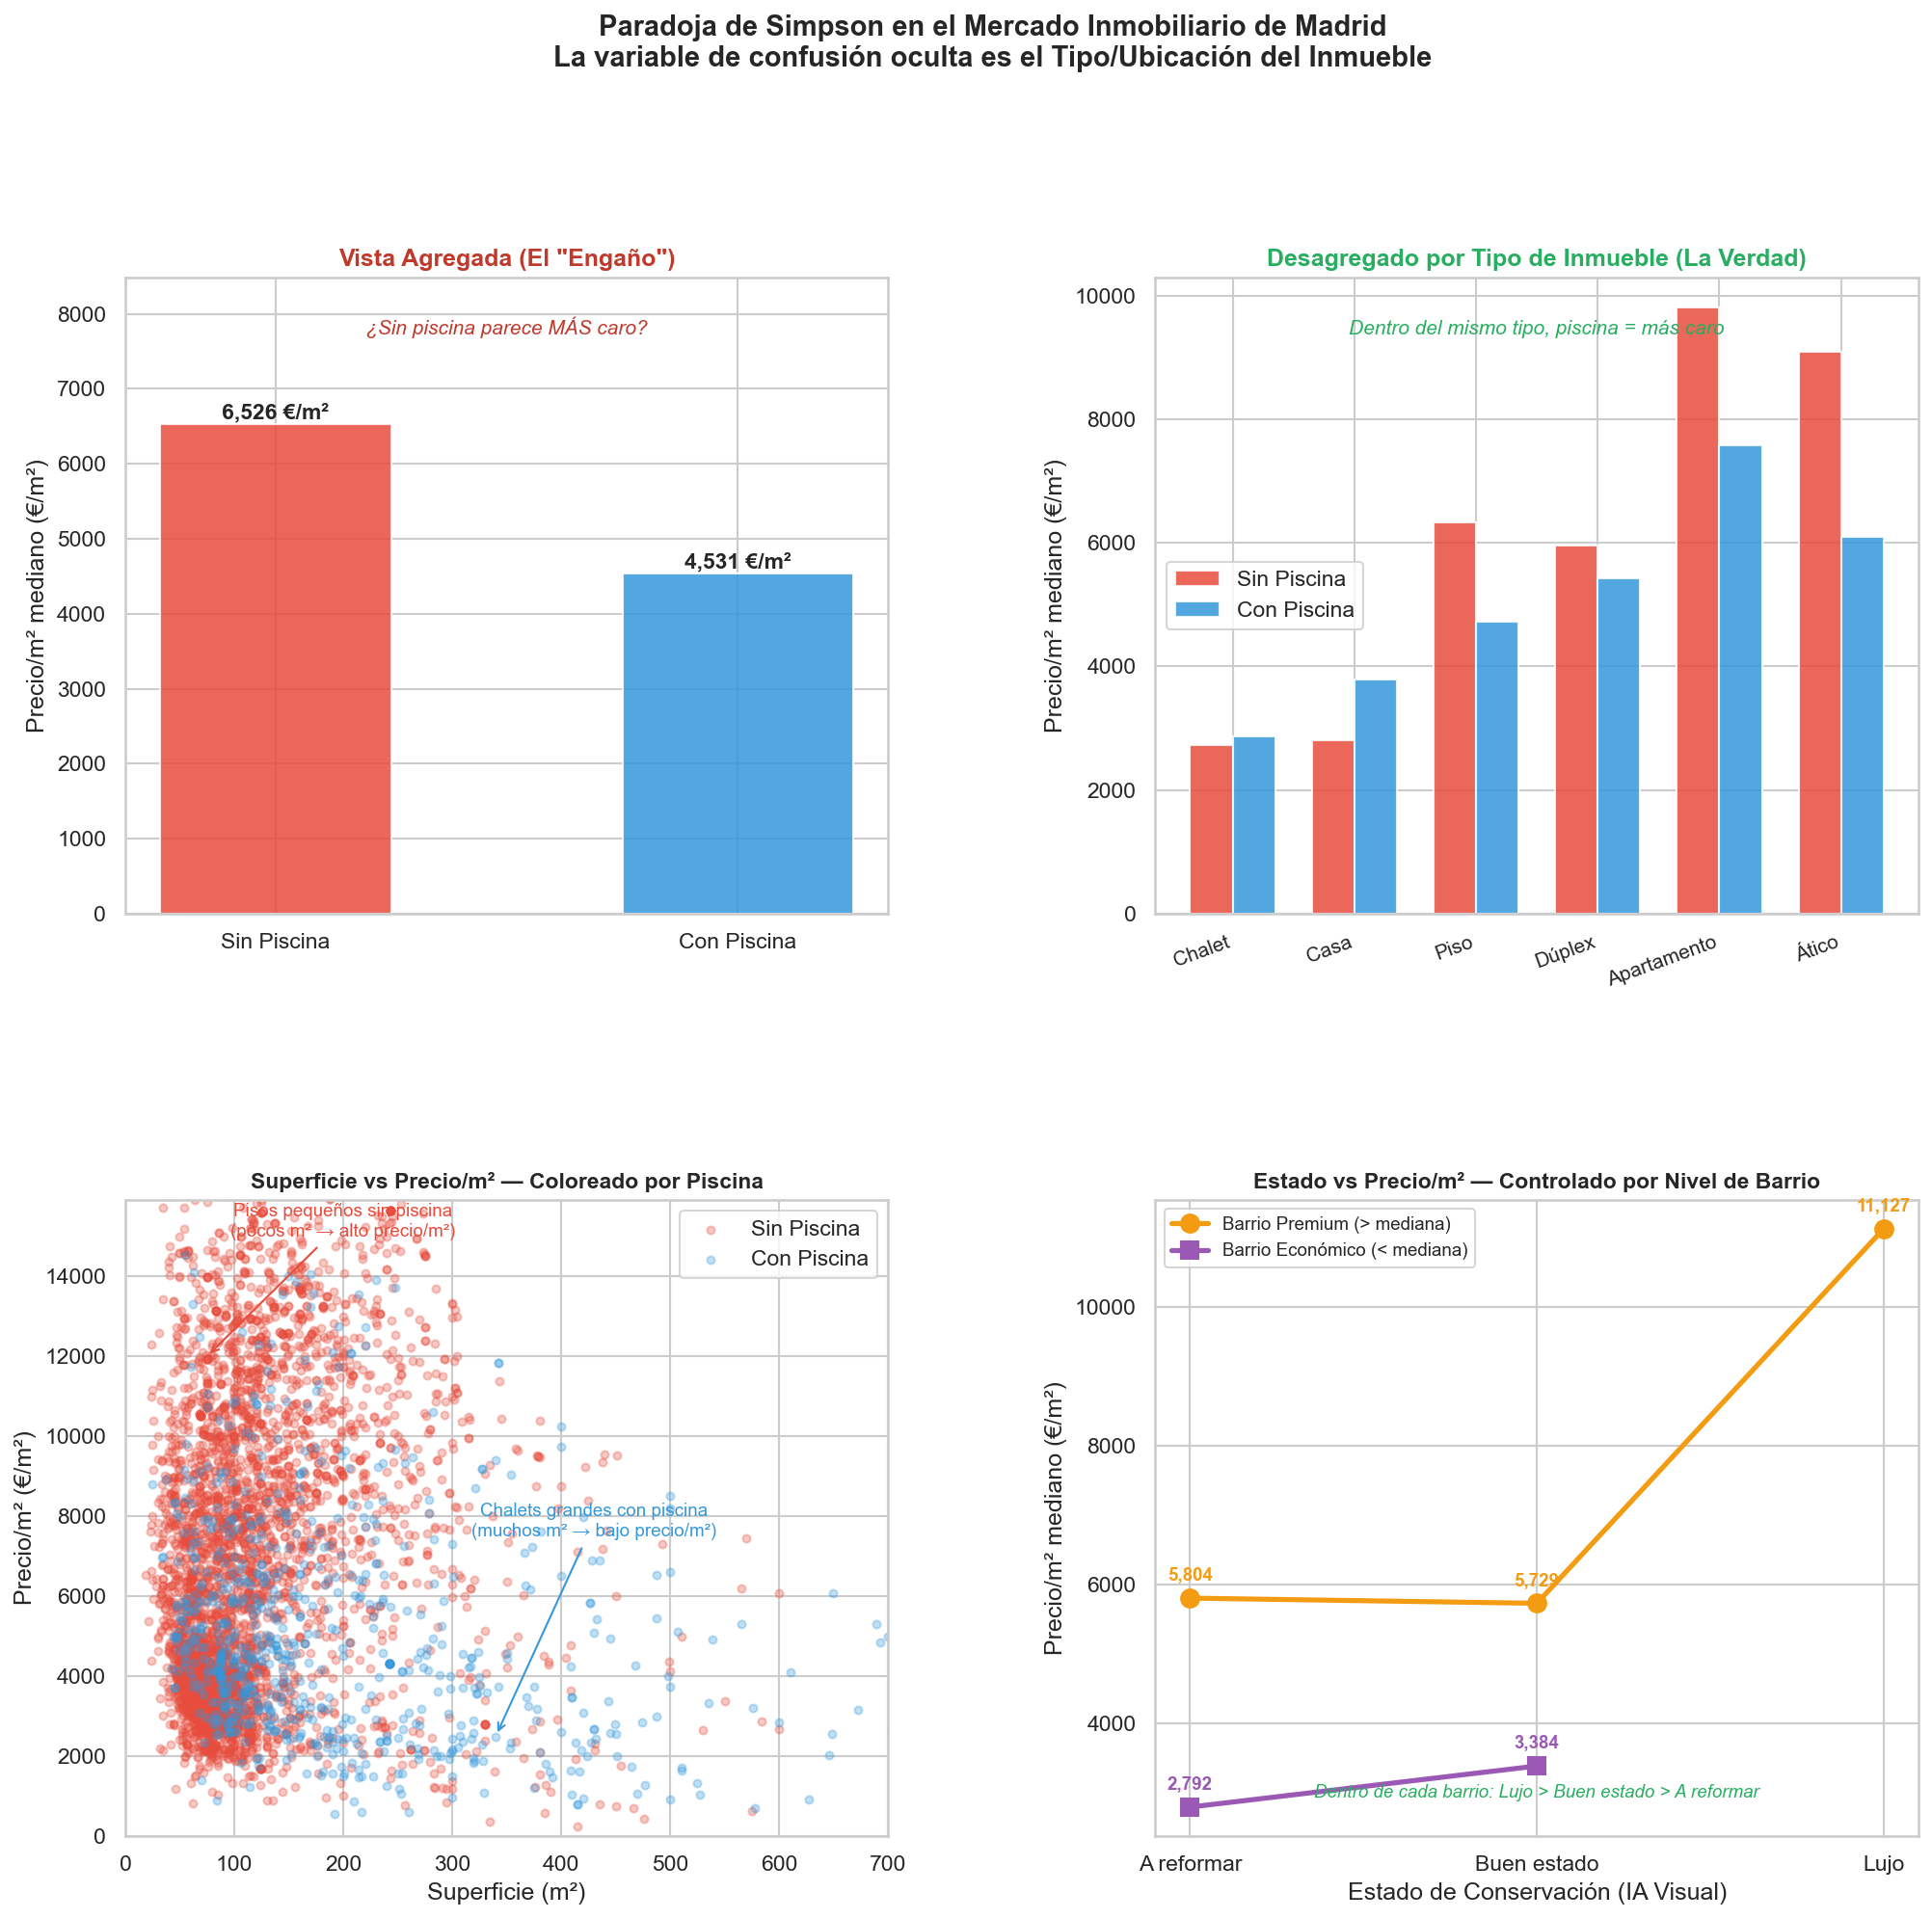

Guardado: A6_Efecto_Simpson.png


In [8]:
# A.6. Demostración de la Paradoja de Simpson en el Mercado Inmobiliario de Madrid
import matplotlib.gridspec as gridspec
import numpy as np

P98 = df['precio_limpio'].quantile(0.98)
df_viz = df[df['precio_limpio'] < P98].copy()

# Solo tipos con suficiente muestra
tipos_ok = df_viz['tipo_inmueble'].value_counts()
tipos_ok = tipos_ok[tipos_ok >= 30].index
df_viz = df_viz[df_viz['tipo_inmueble'].isin(tipos_ok)]

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── PANEL 1 (arriba izq): Vista agregada "el engaño" ──
ax1 = fig.add_subplot(gs[0, 0])
medians_piscina = df_viz.groupby('tiene_piscina')['precio_m2'].median()
bars = ax1.bar(['Sin Piscina', 'Con Piscina'], medians_piscina.values,
               color=['#e74c3c', '#3498db'], alpha=0.85, width=0.5, edgecolor='white')
for bar in bars:
    val = int(bar.get_height())
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 80,
             f"{val:,} €/m²", ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Vista Agregada (El "Engaño")', weight='bold', fontsize=12, color='#c0392b')
ax1.set_ylabel('Precio/m² mediano (€/m²)')
ax1.set_ylim(0, medians_piscina.max() * 1.3)
ax1.text(0.5, 0.91, '¿Sin piscina parece MÁS caro?', transform=ax1.transAxes,
         ha='center', fontsize=10, color='#c0392b', style='italic')

# ── PANEL 2 (arriba dcha): Desglose por tipo de inmueble ──
ax2 = fig.add_subplot(gs[0, 1])
tipos_order = ['Chalet', 'Casa', 'Piso', 'Dúplex', 'Apartamento', 'Ático']
# Normalizar nombres
df_viz['tipo_norm'] = df_viz['tipo_inmueble'].str.strip()
tipos_en_datos = [t for t in tipos_order if t in df_viz['tipo_norm'].unique()]
if not tipos_en_datos:
    # Fallback: usar los que haya
    tipos_en_datos = df_viz['tipo_norm'].value_counts().head(5).index.tolist()

x = np.arange(len(tipos_en_datos))
width = 0.35

for j, (tiene, color, label) in enumerate([(0, '#e74c3c', 'Sin Piscina'), (1, '#3498db', 'Con Piscina')]):
    vals = []
    for tipo in tipos_en_datos:
        sub = df_viz[(df_viz['tipo_norm'] == tipo) & (df_viz['tiene_piscina'] == tiene)]
        vals.append(sub['precio_m2'].median() if len(sub) >= 5 else np.nan)
    ax2.bar(x + j * width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')

ax2.set_xticks(x + width / 2)
ax2.set_xticklabels(tipos_en_datos, rotation=20, ha='right', fontsize=10)
ax2.set_title('Desagregado por Tipo de Inmueble (La Verdad)', weight='bold', fontsize=12, color='#27ae60')
ax2.set_ylabel('Precio/m² mediano (€/m²)')
ax2.legend()
ax2.text(0.5, 0.91, 'Dentro del mismo tipo, piscina = más caro', transform=ax2.transAxes,
         ha='center', fontsize=10, color='#27ae60', style='italic')

# ── PANEL 3 (abajo izq): Scatter superficie vs precio/m2 coloreado por piscina ──
ax3 = fig.add_subplot(gs[1, 0])
for tiene, color, label in [(0, '#e74c3c', 'Sin Piscina'), (1, '#3498db', 'Con Piscina')]:
    sub = df_viz[df_viz['tiene_piscina'] == tiene]
    ax3.scatter(sub['m2'], sub['precio_m2'], c=color, alpha=0.3, s=15, label=label)

ax3.set_xlabel('Superficie (m²)')
ax3.set_ylabel('Precio/m² (€/m²)')
ax3.set_title('Superficie vs Precio/m² — Coloreado por Piscina', weight='bold', fontsize=11)
ax3.set_xlim(0, 700)
ax3.set_ylim(0, df_viz['precio_m2'].quantile(0.97))
ax3.legend()
ax3.annotate('Chalets grandes con piscina\n(muchos m² → bajo precio/m²)',
             xy=(340, 2500), xytext=(430, 7500),
             arrowprops=dict(arrowstyle='->', color='#3498db'), fontsize=9, color='#3498db', ha='center')
ax3.annotate('Pisos pequeños sin piscina\n(pocos m² → alto precio/m²)',
             xy=(75, 12000), xytext=(200, 15000),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'), fontsize=9, color='#e74c3c', ha='center')

# ── PANEL 4 (abajo dcha): Estado conservación controlado por nivel de barrio ──
ax4 = fig.add_subplot(gs[1, 1])
df_ia = df_viz[df_viz['estado_conservacion'] != 'No etiquetado'].copy()

precio_med_barrio = df.groupby('barrio_limpio')['precio_m2'].median()
umbral = precio_med_barrio.median()
df_ia['nivel_barrio'] = df_ia['barrio_limpio'].map(
    lambda b: 'Barrio Premium (> mediana)' if precio_med_barrio.get(b, 0) >= umbral
    else 'Barrio Económico (< mediana)'
)

orden_estado = ['A reformar', 'Buen estado', 'Lujo']
for nivel, ls, marker in [
    ('Barrio Premium (> mediana)',  '#f39c12', 'o'),
    ('Barrio Económico (< mediana)', '#9b59b6', 's')
]:
    sub_nivel = df_ia[df_ia['nivel_barrio'] == nivel]
    medians_est = [
        sub_nivel[sub_nivel['estado_conservacion'] == e]['precio_m2'].median()
        for e in orden_estado
    ]
    ax4.plot(orden_estado, medians_est, marker=marker, linestyle='-', color=ls,
             linewidth=2.5, markersize=9, label=nivel)
    for i, val in enumerate(medians_est):
        if not np.isnan(val):
            ax4.text(i, val + 250, f'{int(val):,}', ha='center', fontsize=9, fontweight='bold', color=ls)

ax4.set_title('Estado vs Precio/m² — Controlado por Nivel de Barrio', weight='bold', fontsize=11)
ax4.set_xlabel('Estado de Conservación (IA Visual)')
ax4.set_ylabel('Precio/m² mediano (€/m²)')
ax4.legend(fontsize=9)
ax4.text(0.5, 0.06, 'Dentro de cada barrio: Lujo > Buen estado > A reformar', transform=ax4.transAxes,
         ha='center', fontsize=9, color='#27ae60', style='italic')

plt.suptitle(
    'Paradoja de Simpson en el Mercado Inmobiliario de Madrid\n'
    'La variable de confusión oculta es el Tipo/Ubicación del Inmueble',
    fontsize=14, weight='bold', y=1.01
)

plt.savefig('graficas_exportadas/A6_Efecto_Simpson.png', bbox_inches='tight')
plt.show()
print("Guardado: A6_Efecto_Simpson.png")


---
## 📊 Sección B — Gráficas Interactivas para la App (Plotly / Streamlit)

> Cada función puede copiarse directamente a `app.py`.  
> **Instrucción de integración**: llama `st.plotly_chart(figX, use_container_width=True)` donde necesites cada gráfica.


In [9]:
import plotly.express as px
import plotly.graph_objects as go

# Paleta y layout base compartida para todas las gráficas de la app
PLOTLY_DARK_LAYOUT = dict(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family="Inter, sans-serif", color="white"),
    title_font=dict(color="white", size=15),
    legend=dict(font=dict(color="white")),
)
COLOR_MAP_ESTADO = {
    "Lujo":          "#f59e0b",
    "Buen estado":   "#10b981",
    "A reformar":    "#ef4444",
    "No etiquetado": "#64748b",
}
print("✅ Plotly configurado.")


✅ Plotly configurado.


### B.1 — Histograma de Precios (Distribución)

In [10]:
# B.1. Distribución probabilística de precios (interactivo)
# ── Para app.py: copia esta función ──────────────────────────────────────────
def make_price_histogram(df):
    fig = px.histogram(
        df, x='precio_limpio', nbins=60,
        title="Distribución Probabilística de Precios",
        template="plotly_dark",
        color_discrete_sequence=["#00d2ff"],
        opacity=0.85,
        labels={'precio_limpio': 'Precio (€)', 'count': 'Nº de Propiedades'},
    )
    fig.update_layout(**PLOTLY_DARK_LAYOUT)
    fig.update_xaxes(title="Precio (€)", tickformat=",.0f")
    fig.update_yaxes(title="Nº de Propiedades")
    # Línea de mediana
    mediana = df['precio_limpio'].median()
    fig.add_vline(x=mediana, line_dash="dash", line_color="#f59e0b", line_width=2,
                  annotation_text=f"Mediana: {mediana:,.0f}€",
                  annotation_position="top right",
                  annotation_font=dict(color="#f59e0b"))
    return fig

fig_b1 = make_price_histogram(df)
fig_b1.show()


### B.2 — Rendimiento vs Superficie por Estado Visual

In [11]:
# B.2. Scatter m2 vs precio coloreado por estado IA
# ── Para app.py: copia esta función ──────────────────────────────────────────
def make_surface_scatter(df, sample_n=3000):
    df_s = df.sample(min(sample_n, len(df)), random_state=42)
    fig = px.scatter(
        df_s, x='m2', y='precio_limpio', opacity=0.5,
        color='estado_conservacion',
        color_discrete_map=COLOR_MAP_ESTADO,
        title="Rendimiento-Superficie vs Estado Físico (CNN)",
        template="plotly_dark",
        labels={'m2': 'Superficie (m²)', 'precio_limpio': 'Precio (€)', 'estado_conservacion': 'Estado IA'},
        hover_data=['barrio_limpio', 'precio_m2'],
    )
    fig.update_layout(**PLOTLY_DARK_LAYOUT)
    fig.update_xaxes(title="Superficie (m²)")
    fig.update_yaxes(title="Precio (€)", tickformat=",.0f")
    return fig

fig_b2 = make_surface_scatter(df)
fig_b2.show()


### B.3 — Micro-Mercados: Dispersión por Barrio

In [12]:
# B.3. Boxplot por barrio (top 15 con más propiedades)
# ── Para app.py: copia esta función ──────────────────────────────────────────
def make_barrio_boxplot(df, top_n=15):
    top_barrios = df['barrio_limpio'].value_counts().nlargest(top_n).index
    df_top = df[df['barrio_limpio'].isin(top_barrios)]
    fig = px.box(
        df_top, x='barrio_limpio', y='precio_limpio',
        color='barrio_limpio',
        title=f"Micro-Mercados: Top {top_n} Barrios por Concentración",
        template="plotly_dark",
        labels={'barrio_limpio': 'Barrio', 'precio_limpio': 'Precio (€)'},
    )
    fig.update_layout(**PLOTLY_DARK_LAYOUT, showlegend=False,
                      xaxis={'categoryorder': 'median descending'})
    fig.update_xaxes(tickangle=-30)
    fig.update_yaxes(tickformat=",.0f")
    return fig

fig_b3 = make_barrio_boxplot(df)
fig_b3.show()


### B.4 — Impacto del Estado IA en el Precio Medio

In [13]:
# B.4. Bar chart: precio mediano por estado de conservación
# ── Para app.py: copia esta función ──────────────────────────────────────────
def make_estado_bar(df):
    df_ia = df[df['estado_conservacion'] != 'No etiquetado']
    df_agg = df_ia.groupby('estado_conservacion')['precio_limpio'].median().reset_index()
    df_agg.columns = ['Estado', 'Precio Mediano (€)']
    orden = ['A reformar', 'Buen estado', 'Lujo']
    df_agg['Estado'] = pd.Categorical(df_agg['Estado'], categories=orden, ordered=True)
    df_agg = df_agg.sort_values('Estado')

    fig = px.bar(
        df_agg, x='Estado', y='Precio Mediano (€)',
        color='Estado',
        color_discrete_map=COLOR_MAP_ESTADO,
        title="Impacto del Estado (IA Visual) en Precio Mediano",
        template="plotly_dark",
        text='Precio Mediano (€)',
    )
    fig.update_traces(texttemplate='%{text:,.0f} €', textposition='outside')
    fig.update_layout(**PLOTLY_DARK_LAYOUT, showlegend=False)
    fig.update_yaxes(tickformat=",.0f", title="Precio Mediano (€)")
    return fig

fig_b4 = make_estado_bar(df)
fig_b4.show()


### B.5 — Mapa 2D de Lujo (Geoespacial)

In [14]:
# B.5. Scatter mapbox extrayendo lat/lon de img_url_3
# ── Para app.py: copia esta función ──────────────────────────────────────────
def make_luxury_map(df):
    if 'img_url_3' not in df.columns:
        print("Columna img_url_3 no encontrada.")
        return None

    df_map = df.copy()
    # Extraer coordenadas del campo URL (formato Idealista/Google Maps)
    df_map['lat'] = df_map['img_url_3'].astype(str).str.extract(r'([0-9]{2}\.[0-9]+)@').astype(float)
    df_map['lon'] = df_map['img_url_3'].astype(str).str.extract(r'@(-[0-9]{1}\.[0-9]+)_').astype(float)
    df_map = df_map.dropna(subset=['lat', 'lon'])
    df_map = df_map[df_map['estado_conservacion'] != 'No etiquetado']

    if df_map.empty:
        print("No hay propiedades con lat/lon y etiquetadas.")
        return None

    fig = px.scatter_mapbox(
        df_map, lat="lat", lon="lon",
        color="estado_conservacion",
        hover_name="barrio_limpio",
        hover_data={"precio_limpio": True, "m2": True, "lat": False, "lon": False},
        color_discrete_map=COLOR_MAP_ESTADO,
        zoom=10, height=550,
        mapbox_style="carto-darkmatter",
        opacity=0.85,
        size_max=12,
        title="Geometría Espacial del Lujo en Madrid",
        labels={'estado_conservacion': 'Estado IA'},
    )
    fig.update_layout(**PLOTLY_DARK_LAYOUT, margin={"r": 0, "t": 50, "l": 0, "b": 0})
    return fig

fig_b5 = make_luxury_map(df)
if fig_b5:
    fig_b5.show()


---
## ✅ Resumen de Archivos Generados

| Archivo | Descripción |
|---------|-------------|
| `graficas_exportadas/A1_Transformacion_Precio.png` | Justificación del Log-Transform |
| `graficas_exportadas/A2_Correlacion.png` | Matriz de correlación features |
| `graficas_exportadas/A3_Impacto_Amenidades.png` | Boxplots Garaje, Piscina, Ascensor, Terraza (mediana) |
| `graficas_exportadas/A4_Validacion_IA.png` | Precio por estado conservación (VLM) |
| `graficas_exportadas/A5_Ranking_Barrios.png` | Ranking de barrios por precio/m² |

Las funciones `make_*` de la **Sección B** son modulares y están listas para copiarse a `app.py`.
